# Hotel Booking Cancellation Analysis

## Main Question

Which booking characteristics are associated with cancellations, and can a simple model predict whether a booking will be canceled?

In [1]:
#Import libraries
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd 

In [2]:
# Check the working directory
print(Path.cwd())

C:\Users\India\Documents\Projects-Dani\hotel-booking-analysis\notebooks


In [3]:
# Load the CSV
data_path = Path("../data/raw/bookings.csv")
df = pd.read_csv(data_path)
print("Rows and columns:", df.shape)
display(df.head())

Rows and columns: (2000, 20)


,booking_id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,market_segment,deposit_type,customer_type,adr,is_repeated_guest,previous_cancellations,booking_changes,total_of_special_requests
0,SYN-00001,City Hotel,1,42,2025,January,1,1,1,0.0,0,NaN,Direct,No Deposit,Transient,105.87,0,0,0,0
1,SYN-00002,City Hotel,0,55,2025,December,0,5,3,0.0,0,NaN,Online TA,No Deposit,Transient-Party,178.38,0,1,0,1
2,SYN-00003,City Hotel,0,40,2024,June,0,3,1,0.0,0,Canada,Online TA,No Deposit,Transient,197.95,0,0,0,1
3,SYN-00004,Resort Hotel,1,123,2024,November,0,2,2,0.0,0,Germany,Corporate,Non Refund,Transient-Party,209.03,0,0,0,2
4,SYN-00005,Resort Hotel,0,146,2025,December,0,3,2,0.0,1,United Kingdom,Offline TA/TO,Non Refund,Transient,158.57,0,0,0,0


In [4]:
# Diagnose a missing-file error
print(Path.cwd())
print(data_path.resolve())
print(data_path.exists())

C:\Users\India\Documents\Projects-Dani\hotel-booking-analysis\notebooks
C:\Users\India\Documents\Projects-Dani\hotel-booking-analysis\data\raw\bookings.csv
True


In [5]:
# List the columns
print(df.columns.tolist())

['booking_id', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'country', 'market_segment', 'deposit_type', 'customer_type', 'adr', 'is_repeated_guest', 'previous_cancellations', 'booking_changes', 'total_of_special_requests']


In [6]:
# Inspect types and completeness
df.info();

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 2000 non-null   str    
 1   hotel                      2000 non-null   str    
 2   is_canceled                2000 non-null   int64  
 3   lead_time                  2000 non-null   int64  
 4   arrival_date_year          2000 non-null   int64  
 5   arrival_date_month         2000 non-null   str    
 6   stays_in_weekend_nights    2000 non-null   int64  
 7   stays_in_week_nights       2000 non-null   int64  
 8   adults                     2000 non-null   int64  
 9   children                   1969 non-null   float64
 10  babies                     2000 non-null   int64  
 11  country                    1708 non-null   str    
 12  market_segment             2000 non-null   str    
 13  deposit_type               2000 non-null   str    
 14  cus

In [7]:
# Summary statistics
display(df.describe())
display(df.describe(include="all").T)

,is_canceled,lead_time,arrival_date_year,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr,is_repeated_guest,previous_cancellations,booking_changes,total_of_special_requests
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1969.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.288500,78.377000,2024.521000,1.080500,3.023500,1.993500,0.342306,0.027000,155.307925,0.099500,0.063500,0.372000,0.830000
std,0.453178,55.238433,0.499684,0.934054,1.737371,0.617777,0.661548,0.162124,43.254188,0.299407,0.299186,0.683264,0.967765
min,0.000000,1.000000,2024.000000,0.000000,1.000000,1.000000,0.000000,0.000000,45.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,37.000000,2024.000000,0.000000,2.000000,2.000000,0.000000,0.000000,125.827500,0.000000,0.000000,0.000000,0.000000
50%,0.000000,66.000000,2025.000000,1.000000,3.000000,2.000000,0.000000,0.000000,153.295000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,107.000000,2025.000000,2.000000,4.000000,2.000000,0.000000,0.000000,183.320000,0.000000,0.000000,1.000000,1.000000
max,1.000000,375.000000,2025.000000,3.000000,7.000000,4.000000,2.000000,1.000000,288.130000,1.000000,3.000000,3.000000,4.000000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,2000,2000,SYN-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotel,2000,2,City Hotel,1171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,2000.0,NaN,NaN,NaN,0.2885,0.453178,0.0,0.0,0.0,1.0,1.0
lead_time,2000.0,NaN,NaN,NaN,78.377,55.238433,1.0,37.0,66.0,107.0,375.0
arrival_date_year,2000.0,NaN,NaN,NaN,2024.521,0.499684,2024.0,2024.0,2025.0,2025.0,2025.0
arrival_date_month,2000,12,September,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stays_in_weekend_nights,2000.0,NaN,NaN,NaN,1.0805,0.934054,0.0,0.0,1.0,2.0,3.0
stays_in_week_nights,2000.0,NaN,NaN,NaN,3.0235,1.737371,1.0,2.0,3.0,4.0,7.0
adults,2000.0,NaN,NaN,NaN,1.9935,0.617777,1.0,2.0,2.0,2.0,4.0
children,1969.0,NaN,NaN,NaN,0.342306,0.661548,0.0,0.0,0.0,0.0,2.0


In [8]:
# Count missing values
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values.head(15))

country                    292
children                    31
booking_id                   0
booking_changes              0
previous_cancellations       0
is_repeated_guest            0
adr                          0
customer_type                0
deposit_type                 0
market_segment               0
babies                       0
hotel                        0
adults                       0
stays_in_week_nights         0
stays_in_weekend_nights      0
dtype: int64

In [9]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows: ", duplicate_count)

Duplicate rows:  0


In [10]:
# Create a clean copy
clean = df.drop_duplicates().copy()

In [11]:
# Fill selected missing values
clean["children"] = clean["children"].fillna(0)

In [12]:
# Create total-guests and total-nights fields
clean["total_guests"] = (
    clean["adults"]
    + clean["children"]
    + clean["babies"]
)

clean["total_nights"] = (
    clean["stays_in_weekend_nights"]
    + clean["stays_in_week_nights"]
)

In [13]:
# Remove clearly invalid rows
clean = clean[clean["total_guests"] > 0]
clean = clean[clean["total_nights"] > 0]
clean = clean[clean["adr"] >= 0]

In [14]:
# Compare before and after
print("Original rows:", len(df))
print("Cleaned rows:", len(clean))
print("Rows removed:", len(df) - len(clean))

Original rows: 2000
Cleaned rows: 2000
Rows removed: 0


In [15]:
# Save the cleaned dataset
processed_path = Path("../data/processed/clean_bookings.csv")
clean.to_csv(processed_path, index=False)
print(processed_path.exists())

True


### Answer Business Questions

In [16]:
# Question 1: What percentage of bookings were canceled?
cancellation_rate = clean["is_canceled"].mean()
print(f"Cancellation rate: {cancellation_rate:.1%}")

Cancellation rate: 28.8%


#### Interpration 
This is a relatively normal cancellation rate considering the industry average rougly sits at ~30%.

In [17]:
# Question 2: Does cancellation rate change with lead time?
clean["lead_time_group"] = pd.cut(
 clean["lead_time"],
 bins=[-1, 7, 30, 90, 180, float("inf")],
 labels=[
 "0-7 days",
 "8-30 days",
 "31-90 days",
 "91-180 days",
 "181+ days",
 ],
)
lead_time_results = (
 clean.groupby("lead_time_group", observed=False)["is_canceled"]
 .agg(["mean", "count"])
)
display(lead_time_results)

,mean,count
lead_time_group,,
0-7 days,0.148148,27
8-30 days,0.255556,360
31-90 days,0.275316,948
91-180 days,0.320652,552
181+ days,0.380531,113


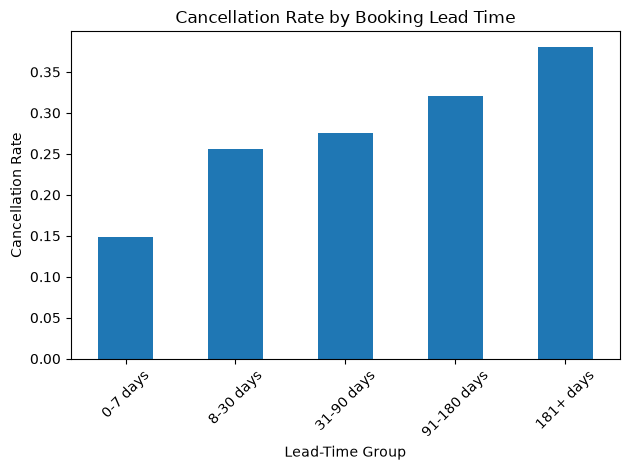

In [18]:
lead_time_results["mean"].plot(kind="bar")
plt.title("Cancellation Rate by Booking Lead Time")
plt.xlabel("Lead-Time Group")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
 "../reports/figures/cancellations_by_lead_time.png",
 dpi=150,
)
plt.show()

#### Interpration 
There is a clear relationship between higher cancellation rates and higher lead times. This means that the longer somebody books in advance, the more likely they are to cancel.

In [19]:
# Question 3: Does deposit type relate to cancellation?
deposit_results = (
 clean.groupby("deposit_type")["is_canceled"]
 .agg(["mean", "count"])
     .sort_values("mean", ascending=False)
)
display(deposit_results)

,mean,count
deposit_type,,
Non Refund,0.428000,250
No Deposit,0.270595,1663
Refundable,0.229885,87


#### Interpration 
Guests without a security deposit are more likely to cancel, by far.

In [20]:
# Question 4: Are repeat guests less likely to cancel?
repeat_results = (
clean.groupby("is_repeated_guest")["is_canceled"]
.agg(["mean", "count"])
)
repeat_results = repeat_results.rename(
index={
0: "First-time guest",
1: "Repeat guest",
}
)
display(repeat_results)

,mean,count
is_repeated_guest,,
First-time guest,0.297057,1801
Repeat guest,0.211055,199


#### Interpration 
Yes, it would appear repeat guests are about 9% less likely to cancel compared with first time guests.

In [21]:
# Question 5: Which months receive the most bookings?
month_order = [
"January", "February", "March", "April",
"May", "June", "July", "August",
"September", "October", "November", "December",
]
monthly_bookings = (
clean["arrival_date_month"]
.value_counts()
.reindex(month_order)
)
display(monthly_bookings)

arrival_date_month
January      158
February     168
March        183
April        158
May          175
June         153
July         174
August       165
September    190
October      152
November     160
December     164
Name: count, dtype: int64

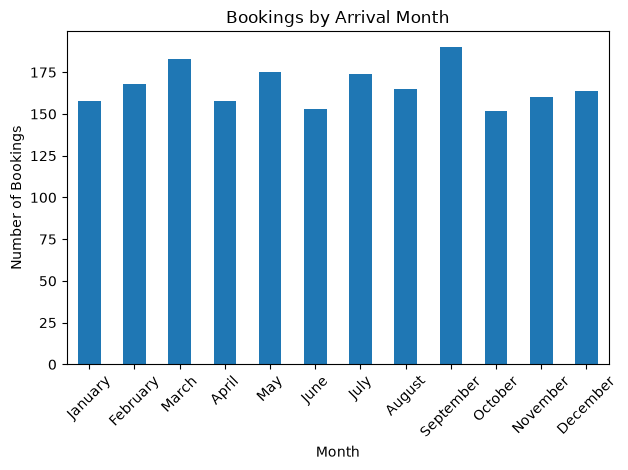

In [22]:
monthly_bookings.plot(kind="bar")
plt.title("Bookings by Arrival Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
"../reports/figures/bookings_by_month.png",
dpi=150,
)
plt.show()

#### Interpration 
Peak times appear to be March and September, while lulls appear to be April, June and October.

## Build and Evaluate a Simple Model

In [25]:
# Import modeling tools
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
ConfusionMatrixDisplay,
accuracy_score,
classification_report,
roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [27]:
#Choose input features
numeric_features = [
"lead_time",
"total_nights",
"total_guests",
"adr",
"is_repeated_guest",
"previous_cancellations",
"booking_changes",
"total_of_special_requests",
]
categorical_features = [
"hotel",
"arrival_date_month",
"market_segment",
"deposit_type",
"customer_type",
]

In [40]:
#Create X and y
features = numeric_features + categorical_features
X = clean[features]
y = clean["is_canceled"]

In [41]:
#Split training and test data 
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y,
)

In [42]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training cancellation rate:", y_train.mean())
print("Testing cancellation rate:", y_test.mean())

Training rows: 1600
Testing rows: 400
Training cancellation rate: 0.28875
Testing cancellation rate: 0.2875


In [50]:
# Build preprocessing pipelines
numeric_pipeline = Pipeline(
steps=[
("imputer", SimpleImputer(strategy="median")),
("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"),),
    ]
)

In [51]:
# Apply each pipeline to the correct columns
preprocessor = ColumnTransformer(
transformers=[
("numbers", numeric_pipeline, numeric_features),
("categories", categorical_pipeline, categorical_features),
]
)

In [52]:
# Create and train logistic regression
model = Pipeline(
steps=[
("preprocessor", preprocessor),
(
"classifier",
LogisticRegression(
            max_iter=1000,
class_weight="balanced",
),
),
]
)
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['lead_time','total_nights','total_guests',...,'market_segment', 'deposit_type','customer_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('categories', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spe

In [53]:
# Generate predictions
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

In [54]:
# Evaluate classification performance
print(classification_report(y_test, predictions))
auc = roc_auc_score(y_test, probabilities)
print("ROC-AUC:", round(auc, 3))

              precision    recall  f1-score   support

           0       0.81      0.60      0.69       285
           1       0.39      0.65      0.49       115

    accuracy                           0.61       400
   macro avg       0.60      0.62      0.59       400
weighted avg       0.69      0.61      0.63       400

ROC-AUC: 0.692


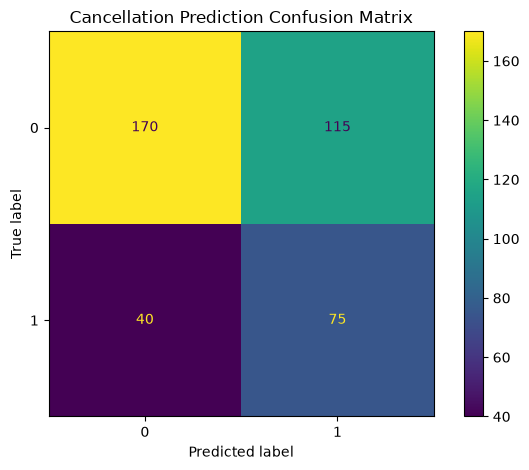

In [55]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_estimator(
model,
X_test,
y_test,
)
plt.title("Cancellation Prediction Confusion Matrix")
plt.tight_layout()
plt.show()

In [56]:
# Compare against a baseline
majority_class = y_train.mode()[0]
baseline_predictions = [majority_class] * len(y_test)
baseline_accuracy = accuracy_score(
y_test,
baseline_predictions,
)
model_accuracy = accuracy_score(
y_test,
predictions,
)
print(f"Baseline accuracy: {baseline_accuracy:.1%}")
print(f"Model accuracy: {model_accuracy:.1%}")

Baseline accuracy: 71.2%
Model accuracy: 61.3%
